## About this fork

Based on [Tufa Labs’ Duck harness — June 30 milestone winner](https://www.kaggle.com/code/jeroencottaar/tufa-labs-duck-harness-june-30-milestone-winner). Full credit to Jeroen Cottaar and Tufa Labs for the original Duck solver and harness.

The Duck prompts, tool-use loop, game policy, and scorer remain unchanged. My changes are limited to model serving and performance:

- Replaced the original Qwen3.6-27B-FP8 serving stack with the pinned `RadixArk/Qwen3.8-Flash-Next-NVFP4` checkpoint.
- Inference optimization: ModelOpt NVFP4 weights, BF16 compute, async scheduling, chunked prefill, native three-token NEXTN MTP speculative decoding32K context, an 8K batched-token cap, eight vLLM sequences, CUDA graphs, disabled prefix caching, and disabled request/access logs. Duck retains 28-way game concurrency.
- Added a pinned offline vLLM runtime and compatibility patch required for the model’s FP8 PLE layers.
- Added an owned-server watchdog that checks `/v1/models`, restarts only after four consecutive failures, confirms the old process and port are gone, and permits at most two restarts.

# Tufa Labs ARC3 submission

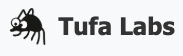

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# Skip periodic JSON/HTML diagnostics and per-frame logging for every run.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1"

# Apply the measured vLLM winner before any serving setup command runs.
PUBLIC25_VLLM_PROFILE_NAME = 'kv5-bf16-mtp3-c8-cg32'
PUBLIC25_VLLM_PROFILE_ENV = {
    "TAAF_VLLM_ENABLE_PREFIX_CACHING": "0",
    "TAAF_VLLM_KV_CACHE_DTYPE": "auto",
    "TAAF_VLLM_KV_CACHE_MEMORY_BYTES": "5368709120",
    "TAAF_VLLM_MAX_CUDAGRAPH_CAPTURE_SIZE": "32",
    "TAAF_VLLM_MAX_NUM_BATCHED_TOKENS": "8192",
    "TAAF_VLLM_MAX_NUM_SEQS": "8",
    "TAAF_VLLM_MTP_TOKENS": "3",
    "TAAF_VLLM_OMP_THREADS": "1"
}
for key, value in PUBLIC25_VLLM_PROFILE_ENV.items():
    os.environ[key] = value
print(
    f'PUBLIC25_VLLM_PROFILE name={PUBLIC25_VLLM_PROFILE_NAME} '
    f'env={json.dumps(PUBLIC25_VLLM_PROFILE_ENV, sort_keys=True)}',
    flush=True,
)
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["keithtyser/duck-qwen38-nvfp4-mtp-vllm-smoke-v1", "keithtyser/qwen38-flash-next-vllm-nvfp4-runtime-v1"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands â€” installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

In [ ]:
DIGESTS_B64 = '/Td6WFoAAATm1rRGAgAhARYAAAB0L+Wj4hyJG5ddAC2ewEZzQ2pRmHeGi/1ckvK3PYoaqakk42Fr3LRZ1fSvUrHdMC8Ue4i1gZ3LQzkOU8J3L15LVWQ3+Hb/LChCJTxQflFuUKELJ0XKmG/Km6T2XmVIdylagPsTA6XViv/Jb7oD3qpBvKelN6jZyA+9+IJQeV2i1SWBkHfqT1QLVYfSEQ8DbYneCssg/VIzO5yw+NF44a7JMbl0i++NygArh+7v4d39aKblT0xL9BwawkT8upqo0QVH5YUHQHcBAVP5PpCyExML4HjjaWC2EZIO8LfKh2e5msSFFi51cX9t+hagyJA20bUk0piVTzY4mNl++4ggVopN+Gtqk1RIb9kHB3OQ2PjUjZr/UNo9mXBn8LD+LSOSbBI64g/lXzMZV3vUvv/P/efeU2ut6EUJ91ydN/9Do+Ypkxi2uP93Ioui+LYk+A9WjKxUjEFznF1dRUAGUbj+JmCnF4LFwifkKErwvR/YDnGrfjYq0IpZlKv6tb0FW1kUwE905ZWH2kbMtOaXDRM1zREXrlTISgGteU1mJ9R4G3DDS6rtMpJnsC4bsYLWOW7oOhcMQohKUzyKK6/Gc6Q6TLzqk+UQCjreArBwn52RXDWqgmc1YUsqQNgYHrewBtChivJ3qii7PqPSFt4N55xb6ELNUdF0JOwhx/dyy61G02Lz7GQBAizQRyItnmJS5bgqtWRzXA9zElKG9O3th1arW4jnvqcLWUX/IvZPOmSEM24u6qTQjPgzYrHt40pmzzLWv+29MM5BHS3X9NOraTG+xWCMj4sqYDBJcSB8SHrhQz1xmOB1efScVgZeReXVVqFD7t1tvfmZfSivXSYSOF3gV581FqyH+IbI9q7bBP8hyRe33dNNhCsuTotVdWe2oT9uens8fatCfa/FDz3OvrlNnftaYQvk8C6m9mIppJu18q4MJ3TkKv7mQKnuHxAQPxHcJINxbQJW/pgq21Py0BOwiuU12u3QcGn4rxNLjqBhzZCigCbih+cysDFU044SvRctIy3VPGPA8oQH+90oMLXIkXtazgnfk03c/cjXDKZXUD4qdPWJicdfoxs+Gk1bwt8ya70goZzOyyDYyykhEV7kQm+OgX+C3n7zEHLohZAqY7SQ4Jdr5/mGuxyWykwg84sih3BDnFMKbTd9KVFWGbrbH/0kR+5/l/+S6jZb7Q8p++8Z1h4z+QCLS3PmxkG2XRuHo8s9mbD0cYHpvbBRsyMW2uQKKfMQEx714LIh1BtzjIpq5Zhw4oXqv2F9+kZ8qK0kzZ5mgG+BpWfq7GDzaCYTa/8l5wZr/yCl4WD2EyJTFD/m3kbxxgZgaGdrXDVeBxxPaejaRJUU2tDMmUAxUT5PyxuHEZX4O7nYyRvlhCKuEHa+NffaR5bUWlad/r89JHZpxuvp+MxWwxfyBMbIXUy3BhSlk7zdOpPMuK7sDXorlHDuK/8W2OOIaJ8CBYAK5fgj5UzNTyxglZV/2UjjJnhVvYt+jJOCqxMOi1IeycdnIZGnXe/8KHYYTjwoc/9hnwlwKCPWzVVdlqZ7lXVCUxSfTZOE6XktGht2FWglpKxd+GsZK32K7WVqwB9U27OhXFNuNW/ClOxbM69d6kTMTkgK5nsPIVzZzDOwiphPU+4soIx2BVARoCNtNW7MnUkYgZiiNJ2RsZGBrRiVnDrBiMyHbTwjIS7Rub0GZy9Bmri5GtXNSFkLP+uKEqBrR346Dhf4jf5n7tV9xDZUkUhOLWXWLbQvZE/2sBMCNY48m3MEai63hqnp26h9R/UKS5//fwPLbx4l9k2MB+3Fm9vkoBHXDo3fMnKArCH/wpC2YA8gNIYpPGXcTwzW7phNGmxGBn+LcPugaA1Q9P/TRIqNc41oKjdWWyB0nUDA/d66zmETUfZJ2Ao9AOUmud1EZK3YHetAeQk6wWq6sRII1CwPmyKaLXlleEZc76+cfCbUUYLWLz/1iMv0MszyysN/QhXlDfhSfi4g8eDEPvZirl4ZkD2SE+/YO1j2BrA4k13T31Yo+a63a5/a6eEBNQQatlRckNTf4LEC0j7g1D7D3HUTnXWnKvTZqQVVkuFB5VHwZ30HIq+X7BOKOmKMKsZn83yKvGyV5tQ4075UNQMc+3M0UY1F92kkVi1M3s3sB4T/0Q47HiE29r9HE6YJjxJMItNu/4s07C+/aFnv6cf683dY8IzPqruXdBdCAnFKro7F9DZpOwGRlxnVxRKVPr5/nUkD2ZvP0tH4PCYVtXO7l0t2m0IiAA/jgB0Z4FJfyrRerH+yXhHaVnGxzBwBT/w5Td8fLzSU+GT1deIuK8m0Z1sFgptolYKnkd6jzKzfURkUPf4f2mDX2TKLE67kerpMfYKmg155IdPZA1EN9HraBINnA9JcXKRKGCWfZSEUgKdmxMwb5OfXKyV58SJN8ZvKtch5F4U+Z0+HduHE8csP6z9ju13oxmWakMfKzstv1171Nrir2P+SKvQFkS2aSBKBN/UHj2CHvP1sF8tZa9O6ha309LulnCWeuvr25A0WLsheGv0TWNneDK8j4dvxAIhSaodoV+oOQHAVvp8Fh6/mt+mA2vOAfoeXRC866MO5AeBkyngeMcB9A/hqiFFK11ucIaK9PhnoSB3BEnopywrSp5rDPiS50vVEV31erUKOoCzu61b5viBlLZXitBs4fJ9QSxQpnHFxKNGMYp2a6XbXj8iVfyFtY2aEPzBPejReQrsnH6m2u1sAISXiQ1UqvCKGy8IVrBWkRtAMazft4BD7Z4+rZlaw03uhkBS+dNZEPnwuhMTy/nF+4fl3v7+HO6jG+AtPF9sgt/MF+oRA9fZ2AB3yp71IXtApayU8GmPqQk44m9IvN2AXX5CgEOdVim1FnmmLBp71njBdfnuCDevfofGojQwjJCJzs3ZJon/zHf1QcUsJxwkA8bc50ior+bJYR5TPPmao4aioEIfGCJxwDqxa0XzdQSOwbiAjz3gzn0EcHzofqp244r+Xv2uVgMIakKjb+1ymmUfZF9m5oZuGMf0o0aicP02NkI02J/ozfH7vHVG6aWgkehIHgKpTg3u7LL0b/6sKNz8ySs7zjmLAshCpPZ+DFTYAkpkAc12G1onY9FF77nlFa65tzl7qXLbTeOhuecBiuBmdwPGdl8LY3yoq/o7PMz8wIuewoApY+8ATPj9GdvRIjx2PktJMB5fj5qDmPkeU1iJDj87fBgMT/d1CNTAejU3fnOwq/LloS9UzZGrUea5OgC9YAdND6RXThF/WmIbd+Qf2ROyJo2us0Ao33B09w2fxgXpDMA4/jijlSHpJis/fMJjzC8yvgkVH44X+B56x/aa/Dm+D6A1b3IT+s/8rEiRjcNlffHnEl3tsVSRRqkyW3Lnw+5YEh8wT5A8TxiRZ7FsHunUs/8/3dU1oWlKb3iG402rU9FD4g03DQx1jOhJro9U4UqCT7MkFkP9UXwx84ByoPS8aTRYcgpp36eLWJQWObKHoV7YqGS6SOLkUGcpsroy8IB6cHSZ/uBbYaCGDY4CIpKs1vs8hs4lHRg+g0SE89jlZpMv2fUYevzmfmdeQqfaw00b6eNsM2ohjGPAxj7fAZNgEbONlnpFwZ9xi7DbsQuAtWmY4wWm54j9wnTcunzPRwAOTjBqRKMSZ4hs3SXwqVGRpYoLGQRYFQKfvSbgDD9z+gPdhJPHf3mnfrNFGcMJmQqBrqWF+37e+TB8+LrFUVjosCMNBS9dBa2vjhQnzfqAiGDK7T/iY968mWqFqcQkdvRsZyqQTetZ3SuaCEW/CH0alttp/+CvRlxgAuRREDebOhgBiwSora+/lTLXzM0ukO4ZBVfR3ynfxGE1CDyWTUSJddPJiKKeGkgI0XGqyk8tGl/L/7bUkykGgIsj0mOrcaneYarcSaNZIFfJxJA71Tg3hlES2vXl/1+gUleFTnCTsqsVFHQck0oQvLPJc1qBOX3lq3syBByhYdVh54+Go2cfadPvCuOvBDwXzmMeo32DBpnNob2VX7YSaKtrBFaxg7GAuPMe/7/bmG0cwKsz6Udvt0aWa8SkuycRqsrDrlL6bZQ2x50On1nm6SwG4DWz/UKZ74ki/Eazdl/cYO2IW9+JVkM7bZZAtRDWmwT563jN8RMDnAHEli1sOlMRW8iQjzMW6LFd3oyzMJWUi19ck2KDiWXuLNmV3NIA1J98w3BIYoanUJxckecS3DQIDvjH0ySVvktZS9wLePv9lViR9Hp6yMroxoRgSlIS3MddCTkzNbMcU2mP2t7oht/KEQTiBAMyM7U1Uzn70q2MmT+dyaYpDgNgqKy3sYadXEv0EAuzVie0bER9g28xzv5manlU4GnPfO1QSMv+9Tx7M0mbGn8pyJkrZ1h2vJRP+YQ3r9FuuToEQR7qOVbg7d8eLo5Cqs5ALl45zcSDtQ3kAoCPL1SzUPLLnfd/n342kfyvcGz+3FNG0Gtsgud2bBAk6e9jofcclQPw3uKgCA6YK34xe5vdXVyCephbQKh+bBJH2hY9XU07ji6BVOIVSVvqgA6aicHMr7DChKcMbVxtETQGGz6xb8b0Vn6NydUKjQ2+pV9QuAyPKaZU/LybZR5zDtrzvUIloAsvxnK+vRLNw3BElefh08eIgYxpKWqzN5rr/besyOLwNwy5lSjthjCzMz/uuzDTg9slBrrajgnCebTHaebJ+MZRZ/dtX8SNEsrW7QpPsswMy0aPolKNkhP3W8aNL1JLauuOlRNJUtStVzL58ZZrVElsuhJfF00NKt0cJH2VlcJTAvSQsLjAiJgVcposzOT0dB8gl6593cemvI6nW2KNp6i8of4zOfBOqkFvF94kZwKMxtyQwLyMSqaqeTfNYzDt+OZEtSdKq0fNvInpfB43dlmAftYzmSUEmzu0MYPkcXURqfkseDLL8pRN0eDXK4lwD/GcaH+EW269ybl/IOopAzOhg51zC/rm/bXFN6gkELYswUKYo1+kIQ+ZGzcSvCQbQZbbTOli6iaSeKphGuRg9itIgXdybyXZRZ2HE+lfOnfrKokAdMDepJ5NBDHyeJYeiYcgiYxqnd3GWCsOl+sicebehmm9ctIez1FiLkHus21JFIiqWi6lj+pQ/bJiwbR7QbAsjewlGIJfyfGW3RyPWl0JjOoCkaLPz3VXHs66wT/Il6OjLXFtqdvKA0mr4NW7+LbuJ54DLNjIBMairHupT7urfOV5zSjJ0QcpAZ0yZaXXdwsh/4QZCmWriepYTeHBxypCqc5yt54gYamL+/XXVcpEd5yXsE2Ozwu7U/eoVYQdghV9O5TGUIbDfzjau5ZKW7JU+HfyN/mlCL7inRtMYVZ8wWjnSWu8lCawTV7Utrq2W7qUCBySKGGq2910z2SaqY407vHTDoECUM2C3cMTyka1kEYmcTgxywzxJcO87A0lZp+L+smLopmgUXujUoFLPR17uS0933d5TeGWKoGDXzRoS4uMbVOqLiIGNhyiWOJ0AIWUDK0QpdRkxmhm38q/Od35EQ/+9iJqjaiWUFGc9Q8opHioQwvOiXL5zdSmUpcHm1dfPgV49TL8KouJc2KnDL8ProiyEQ+X8FCI0vrPoGn7/TyJuuIG5DR33AXJdm6Pu0NTyyzVQB1w0GDIeX0GQgfQQnL8Uhwa7slFyA2z4Vp2kZ/1kMIySD63QuIMD8pCtW4HKyq/J36NRsNq4uWYzdzxR1ux3o4/LSMboLrbc9EXecBiUrtPjTlR01S7DnoIS/bdanJ++axVUcBJL1eUluRA7AFXzGHbgXEE0QMDBfDAoR5rU/MJBZ3s5RVgKgE5s8qjzHROL/ob+Whn1vsIAdqO3pQsetUdrc98i6hll0slI+KQ5vJG1w1DYNotDMCRvJvLT+YSwYJlB+uV1G/m3/xmmI6KOAF4L2YFRoOXF7kYttzqbeVlzCIcP2vynGcLS6KoY4OqwJ0Fpad56nSgzJ3zJTTsaEZfetICrYchrrEFttiTL2N6JMm9r/TpZKgF+UkKMsa0Hz4LLt0n2sSVjgMtVrR7Mw5CySdy8MYXEI01hqupJfm47OdmuhJTRWXMSFtEEt9MsJb78O6h4AK71MputUc1usSu2wi5yOaycxfeb+WmhyLxoF1G+pnDA9whXggyzwYBY0k955QqpDE4WPZbPtlUUHKEA+PUo9FWZyPcXDGOZ/dxIVmCva2wGpMNga/6ua1ld7LjpIpJ3nLqMog79Zm5T/owAE8IOrbEj2NTRP6NiG9/ar6GwarG1T92oQLVXJyrkp7iAoC5111bbSFk0m3+42eZU8cw7+bs2Yw9psnNKWWdOGu+2LWQl2B04imdXxJWjV6uDcSf0IsWnzZI9e1znEFBMn9/YoAicRiOMFTlz1H0ZIIoAB6bO7y2McVNhWE6dy+4MF/rDBmiWYYKyGTAwVxwvAkS6gKrC2ad8t8f2WvqFQv5oQfW78u3YG3efeoApegIvITXd7hzQWJtxKDSV/xTRnjbRWLyEhVlKy0/C/tM829Kk3wZUN4mEPsauyPy9ZcgS9DoXy+6fbPbxAz2BPoO+YrALFtGoPRJTrL2WQoMXeLw+u4wifEz7HC1LfFctUincIcYdMUHkT3sBJkN4EUKpRN4Q4Z/oKC70TaoKnu51rA5nnJ+fzbxH7uWi3Q+yiW1EcPs9K1wPT6gb33RxnLfRANll/YUD6lLgMxCTVHTSvCW+j/kmxG2IbI8RE59c5JxSetCRzLxWqsyktWKL8+eQ6yMcIFcdhVL4RxRrTsf0Ts2Aca1/LQKaIxR6hjpBpwQP71jV2GIB3/uMdOoexlm/FDrWgelPFHFKU9jR0B3OLQYWUia56u27sDeyPX8pKG5wixfsQjVN0QN9vt9rcSJYt9mciErItK0vEbG4HryME/RFkaGj96pUdUv/NT3b7aXwGeHQdFmVJESvaE/isHedece29gF9Qhzjzj2sNeSLv5H+oUiEm10VoQTzrwE/uE8L6BmZxmBdTkop9JAbIucBjMCteGNC1zg5HXvipLjna4khSGjRZGVoMAj4Z39KYmLjBSTW1zHTw8nv10iVTL3EVmmCuikIOnh7NDtMYutmQ0t1ZpCPgJTKaCk8UsSVJZdv5uWnf3WPrTazKJCFT+3PCm9d3z2BU2gLdg728iIrTYjbfkpizJlwN9SSGQrD4qg2iJav0xUXBhC7DcTaHt7Jf8s5Q95lwmDKdP4uiDhJUWFsasabaJ7XPs0pizdh82fjdeyzQnx9ySMWbRRR0mnNjuQkPPr3MsixZi9GEAVGd77+sqzNaXIR5G35jhYnMyu7GUvuf1kzhII15o7LRTROcwCBN5dPIjPNr2SoLwpDn4sZEHlI5fHdpoj9j8mlOawLp5BAMQq+7ezTqltKK9GYx+OSGPUsLFKXxLw5NyxVNZwvxV95DfhIofFaSJVZCl/rwGN/iWiPMzMAQZWqzaBLm7xD/gd+u8/KKEGTd4mGJM4ecGDKYBPjZoAbl5Dr5+CHTxtttuMDuOhIY/fgstltftOAn+qL/jHauy+9L1LtDygXVEFC0K8/C4mClOCR5Jxkw1H77Ho37e5faBFDtr3babyhJcIvcTinFpA7fEilpM9+U3zbAas9rWovDo9RCRRZL0M9EWbXHSRjekyIG7nTh2OmTsSpVdGF/JvorzvPFAL1AQdUEkrMnI2+36gnr/bIJ5f6eEZiBShQR3azuuSsvANV7qry+UElh2dh7tUk6bKvuTxxwmSKbIpG6c8QvlipdpSR9/qy2Ip/V2c2o2RjzOFDw/ysihNxUHPqaVV6TWS9+wa1jwu/8xFaDxJ4QJFrrKDLJqcuFlGWbIQchyadn/6e/24f/cKudcyuss3pcD2dSt9dbhk61rEtDlv3hEinowv22im/3BSNJkZqWu1vrG77YCRoU6HQm7TjBWyHu7v66G0VEXqXePGdm3nCzRghQVU/kH1o7Ru1kzkm271H9dJZ8j8pUeciuON+CzyPyTHE56OfMPMK/+bw0z6Y9PEu6i/tnJpEimFlKQWvrNxhIcnu7wTvgzu7nRnkNEC+b/i+uAwkmuSl+FKPsQOW3AEYivjcKetsEYGSW3VWwICn0qLGRK86ZUT4mOsuYd8OluOvkU5GtAYvshO89aHjA0Dbm7mJJvj4PwqfD5ZlQSIx/vl0fQ69Bb2k++69TWpnroLpTMo0swz8lkTSPykhv3Vo3RsFeOuLp92eQx9MDLqHWVFrMxZo8oC07koBSSyuhoMYz7zgp+9WcKx7c+EoJjffruSz3K3nK3luqer/G/tR+UJV/UAFbklR008JEQ+ycurT/Tg8N7cEJK54shuvfEREUXRCMu3OaS+PJxVd11Mzd4GUc49aPZoM3TlaH99CN5oV8RpCKSxLakNHuyTuSZrRzlF9xzSM3phqtA8zQJtbf7PDPkpZaRuKfv1sXkPEFy5+gLl7Qvv8tAET7MeQSmK/ClRR1r6mBRRK3+KBrJKibNOwLAeWlSDobMYJX+g2jg5WNZBO5bgzpkdHMpYWVhX47gfc3ZVhkW0kft+wi5NDzopM9MUZhLAjx90v1nY9Qwr0doAyRfRbD31w3oVrb5LR6WGVBTU24Y+2hK4VDd1HmzsNck5Epnmt5dzh8kJ9nyQT5Dmzl1oG615XwdWpTR3E2nSHyc0cDFAAZbICtUJkrFi4ROde2FKe0rvAWV7GjgIpk7L5QaXC5aXbD37w5PQgPijr52+fggfe0Xf08x4hMByJur5kzezc2F8VOZlE3vnpzPoX0PTjxVmbTKKcmHK/gt6G5sOZrO7bkDDF1yuoB+2dzBV0tmGHwaBjKSdv8TAxu+ScDkKdzHnGCdeQbgI5QeMbaOuvZfkUb5QHKg5K4C/I5mtOcfbnfJJiAqJyEmgqxZOqT9V6W9sfX/SVtGulTIx/qZ5q6z3vwiBLRXp1hIitLvQVuqgzDiWBIQdch4OmiSkveugwwVAchjdH58khM/iquV42jRlGc4CpKn5Wk8ygVtOG5+L3zoITOspT7aLO66oqp/+0hV+5lhhGUcsrqHWkwwa2Q7J1DWsnU2wr6sVRR7JkaIzvLNxibJEbS2l7/Xxw3cu09HCFcH+5daWYhFZWdbTLRWyAtwic9prlkwpn+T28O1hxrh98BtuvdxXd+C6zRx4u+rD4fTul2bZsiwkVi0S3mUWZnrTF597k4LYKN/l+1GSitfIAhxfykNXuTRUOC5lIhzJEImvzTIK0VAQWq8MWp1qgiW+IerfMSWEg29WDpk3tJZQ9WPAF68kCJv3znhAa5CN9XicdCEzQKSbyeCxI9pDNzgmfhaEkWPUoalYq68swp9PNoo8A+iyO0AW+AE3yb2RkGkkuqWt89AftBLj1U3hYk7C/mBL9hWI3hUp33VP8blYX6V90e40Ak2uXAUyxjaQ2Hru1zYN9ac1UFHqUvUPNmCl0RFnBrd5GSPJ5T9xPS4CZEDhTqlwK6vcAAF3mNAmGzgF2AAGzN4q5CABYyLjMscRn+wIAAAAABFla'

# =====================================================================
# ПАКЕТНЫЙ СИНТЕЗ ПРОГРАММ МОДЕЛИ МИРА: 20 попыток на игру по готовым сводкам, без игры.
# Промпт, инструмент и разбор ответа — дословно из scripts/wm_synth_generate.py.
# =====================================================================
import base64 as _b64, json as _json, lzma as _lz, re, time as _t, threading as _th
import json  # разбор ответа из генератора зовёт json.loads; без этого программы из вызова инструмента
             # терялись молча (исключение внутри try) — поймано сухим тестом 11.09
import urllib.request as _ur
from concurrent.futures import ThreadPoolExecutor as _TPE

_BASE = "http://127.0.0.1:1234/v1"
_MODEL = "Qwen/Qwen3.8-Flash-Next-NVFP4"
_DIG = _json.loads(_lz.decompress(_b64.b64decode(DIGESTS_B64)).decode("utf-8"))
_ATTEMPTS = 20
_MIN_PAIRS = 10
_CONC = 16
_SAMPLING = {"temperature": 0.9, "top_p": 0.95, "top_k": 20, "max_tokens": 8192,
             "chat_template_kwargs": {"enable_thinking": True}}
_OUT = WORKING_DIR / "programs.json"

SYSTEM = (
    "Ты — агент-синтезатор модели мира. Ты НЕ играешь: твоя работа — написать на Python "
    "программу, которая ВЕДЁТ состояние игры много шагов подряд.\n"
    "ОТВЕЧАЙ ВЫЗОВОМ ИНСТРУМЕНТА `python`, положив программу в аргумент `code`.\n"
    "В программе ровно две функции:\n"
    "  def state_of(frame): ...   # структурное состояние кадра; ОБЯЗАТЕЛЬНО включи wm_level(frame)\n"
    "  def predict(state, action): ...   # следующее состояние или None, если случай не покрыт\n"
    "Доступны помощники: wm_level(frame), wm_objects(frame) — объекты с полем 't' (подпись цвета и\n"
    "формы без привязки к позиции), 'x', 'y', 'w', 'h', 'pixels'; frame.ascii — сетка символов.\n"
    "КАК ТЕБЯ ОЦЕНИВАЮТ: программу раскатывают от разных состояний и смотрят, сколько шагов подряд "
    "она предсказывает верно. Принимается та, что держится восемь шагов и дольше. Поэтому пиши "
    "правило на ТИП объекта, а не на координаты, и не подгоняй ответ под отдельные записанные "
    "переходы — подгонка ломается на втором шаге.\n"
    "Не больше 60 строк, без объяснений и примеров."
)

TOOLS = [{
    "type": "function",
    "function": {
        "name": "python",
        "description": "Верни программу модели мира: две функции state_of(frame) и predict(state, action).",
        "parameters": {"type": "object",
                       "properties": {"code": {"type": "string", "description": "Программа из двух функций."}},
                       "required": ["code"]},
    },
}]

def pick_code(msg: dict) -> tuple[str, str]:
    """Четыре канала по убыванию надёжности — та же цепочка, что в боевой сборке v11+."""
    def from_calls(calls):
        for c in calls or []:
            fn = (c or {}).get("function", {}) or {}
            args = fn.get("arguments", "")
            if isinstance(args, str):
                try:
                    args = json.loads(args or "{}")
                except Exception:
                    args = {}
            if isinstance(args, dict) and args.get("code"):
                return str(args["code"])
        return ""

    code = from_calls(msg.get("tool_calls"))
    if code:
        return code, "вызов инструмента"
    content = msg.get("content") or ""
    reasoning = msg.get("reasoning") or msg.get("reasoning_content") or ""
    for text, name in ((content, "content"), (reasoning, "канал рассуждений")):
        if not text:
            continue
        blocks = re.findall(r"```(?:python)?\s*(.*?)```", text, re.S)
        if blocks:
            return blocks[-1].strip(), name
        if "def predict" in text and "def state_of" in text:
            return text.strip(), name + " (без ограды)"
    return "", "кода нет"

def _get(url, timeout=10):
    with _ur.urlopen(url, timeout=timeout) as r:
        return r.read()

_t0 = _t.time()
while True:
    try:
        _get(_BASE + "/models"); break
    except Exception as _e:
        if _t.time() - _t0 > 1800:
            raise RuntimeError("сервер не поднялся за 30 минут: %r" % (_e,))
        _t.sleep(10)
_games = [g for g in _DIG if g["pairs"] >= _MIN_PAIRS]
_jobs = [(g, i) for g in _games for i in range(_ATTEMPTS)]
print("SYNTH: сервер готов через %.0f с; игр %d, попыток на игру %d, запросов %d, разом %d"
      % (_t.time() - _t0, len(_games), _ATTEMPTS, len(_jobs), _CONC), flush=True)

_res, _lock = [], _th.Lock()

def _one(job):
    g, i = job
    rec = {"game": g["game"], "attempt": i, "level": g["level"], "pairs": g["pairs"]}
    t = _t.time()
    body = {"model": _MODEL, "messages": [{"role": "system", "content": SYSTEM},
                                          {"role": "user", "content": "Наблюдения:\n" + g["digest"]}],
            "tools": TOOLS, "tool_choice": "auto", "stream": False, **_SAMPLING}
    try:
        req = _ur.Request(_BASE + "/chat/completions", data=_json.dumps(body).encode("utf-8"),
                          headers={"Content-Type": "application/json"})
        with _ur.urlopen(req, timeout=1800) as r:
            resp = _json.loads(r.read())
        ch = (resp.get("choices") or [{}])[0]
        code, channel = pick_code(ch.get("message") or {})
        rec.update({"code": code, "channel": channel, "finish": ch.get("finish_reason"),
                    "usage": (resp.get("usage") or {}).get("completion_tokens", 0)})
    except Exception as e:
        rec.update({"code": "", "channel": "сбой", "error": repr(e)[:200]})
    rec["seconds"] = round(_t.time() - t, 1)
    with _lock:
        _res.append(rec)
        if len(_res) % 10 == 0 or len(_res) == len(_jobs):
            _OUT.write_text(_json.dumps(sorted(_res, key=lambda r: (r["game"], r["attempt"])), ensure_ascii=False))
            got = sum(1 for x in _res if "def predict" in (x.get("code") or ""))
            print("SYNTH [%d/%d] программ %d, прошло %.0f с" % (len(_res), len(_jobs), got, _t.time() - _t0), flush=True)
    return rec

with _TPE(max_workers=_CONC) as _pool:
    list(_pool.map(_one, _jobs))
_OUT.write_text(_json.dumps(sorted(_res, key=lambda r: (r["game"], r["attempt"])), ensure_ascii=False))
_chan = {}
for _r in _res:
    _chan[_r.get("channel", "?")] = _chan.get(_r.get("channel", "?"), 0) + 1
print("SYNTH ИТОГ: программ %d из %d попыток; каналы %s; обрезано по длине %d"
      % (sum(1 for x in _res if "def predict" in (x.get("code") or "")), len(_res), _chan,
         sum(1 for x in _res if x.get("finish") == "length")), flush=True)

for _cmd in _json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
    print("SYNTH teardown: %s" % _cmd, flush=True)
    subprocess.run(_cmd, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())
